<a href="https://colab.research.google.com/github/eka-smnlg/Gold_Price_Prediction_GARCH_LSTM/blob/main/data_emas_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error
import math

In [ ]:
# Load data
data = pd.read_csv('/harga_emas_clean.csv')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

In [ ]:
# Fokus pada kolom harga emas
prices = data['Price'].values.reshape(-1, 1)

In [ ]:
# Normalisasi data
scaler = MinMaxScaler(feature_range=(0, 1))
prices_scaled = scaler.fit_transform(prices)

In [ ]:
# Pembagian data (80% training, 20% testing)
train_size = int(len(prices_scaled) * 0.8)
train_data, test_data = prices_scaled[:train_size], prices_scaled[train_size:]

In [ ]:
# Membentuk dataset untuk model CNN-LSTM
def create_dataset(data, time_step=7):
    X, Y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        Y.append(data[i+time_step])
    return np.array(X), np.array(Y)

time_step = 7
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [ ]:
# Ubah bentuk data sesuai kebutuhan CNN-LSTM
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [ ]:
# Membangun model CNN-LSTM
def build_model():
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(time_step, 1)))
    model.add(MaxPooling1D(pool_size=2))
    # Remove the Flatten layer to keep the output 3-dimensional
    #model.add(Flatten())
    model.add(LSTM(50, return_sequences=True)) # This LSTM layer now receives 3D input
    model.add(LSTM(50))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    return model


=== Training dengan Epoch 50 ===
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0180 - val_loss: 0.0025
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 8.9489e-05 - val_loss: 3.4829e-04
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5.9242e-05 - val_loss: 1.7077e-04
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.7338e-05 - val_loss: 2.1086e-04
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 4.6922e-05 - val_loss: 2.8369e-04
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.3824e-05 - val_loss: 3.8151e-04
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.7912e-05 - val_loss: 3.4931e-04
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.7325e-05 - val_loss: 5.0945e-04
Epoch 9/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.7206e-05 - val_loss: 2.8673e-04
Epoch 10/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.2028e-05 - val_loss: 5.2624e-04
Epoch 11/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.6452e-05 

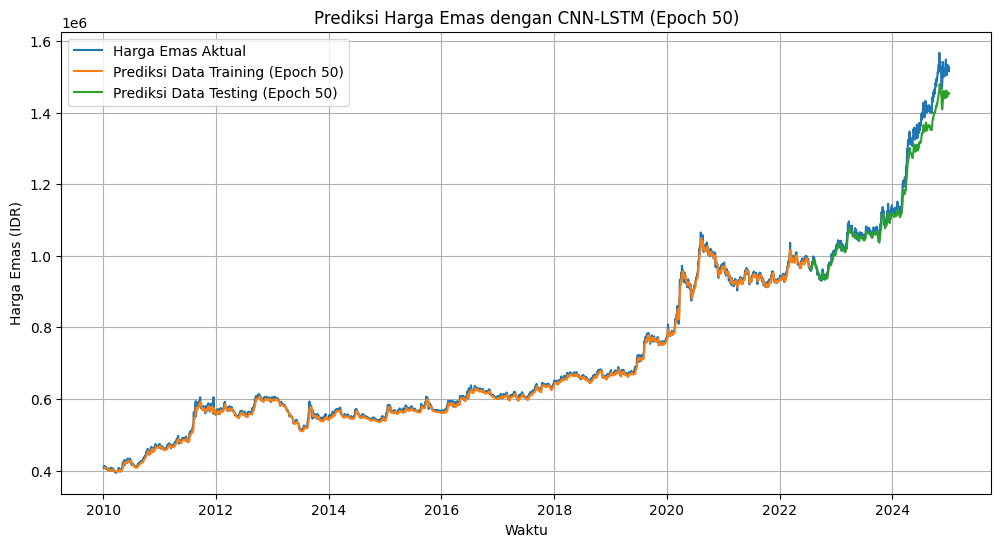


=== Training dengan Epoch 100 ===
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0263 - val_loss: 0.0021
Epoch 2/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.0262e-04 - val_loss: 6.5775e-04
Epoch 3/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.1156e-05 - val_loss: 1.7122e-04
Epoch 4/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.6045e-05 - val_loss: 1.2671e-04
Epoch 5/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.6583e-05 - val_loss: 1.9046e-04
Epoch 6/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.2295e-05 - val_loss: 2.0769e-04
Epoch 7/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.6376e-05 - val_loss: 3.2331e-04
Epoch 8/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.2583e-05 - val_loss: 2.9686e-04
Epoch 9/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5.0199e-05 - val_loss: 4.8725e-04
Epoch 10/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.4798e-05 - val_loss: 3.9224e-04
Epoch 11/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.90

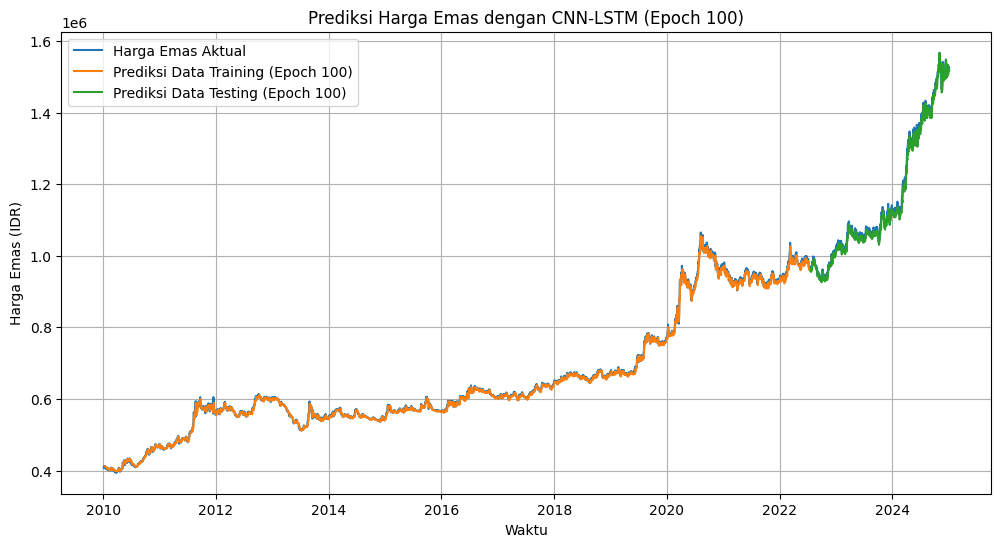


=== Training dengan Epoch 150 ===
Epoch 1/150


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0192 - val_loss: 9.5513e-04
Epoch 2/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 8.3984e-05 - val_loss: 3.2291e-04
Epoch 3/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.0959e-05 - val_loss: 1.2740e-04
Epoch 4/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.3570e-05 - val_loss: 1.2882e-04
Epoch 5/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.6400e-05 - val_loss: 1.8294e-04
Epoch 6/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.9774e-05 - val_loss: 1.9903e-04
Epoch 7/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.8077e-05 - val_loss: 2.8462e-04
Epoch 8/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.1045e-05 - val_loss: 4.0024e-04
Epoch 9/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.2440e-05 - val_loss: 2.2917e-04
Epoch 10/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.0039e-05 - val_loss: 6.2262e-04
Epoch 11/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5

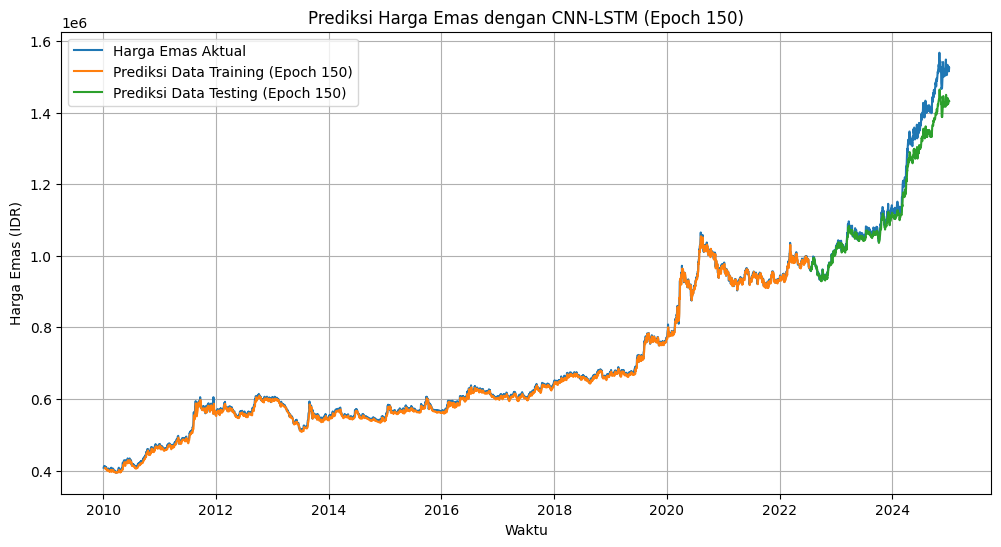


=== Rekap Hasil RMSE ===
Epoch 50 - Train RMSE: 6991.0723, Test RMSE: 34258.9690
Epoch 100 - Train RMSE: 5811.5114, Test RMSE: 13236.1043
Epoch 150 - Train RMSE: 5974.8455, Test RMSE: 42606.3708


In [ ]:
# Training dan evaluasi dengan berbagai epoch
results = {}
for epoch in [50, 100, 150]:
    print(f'\n=== Training dengan Epoch {epoch} ===')

    # Membangun model
    model = build_model()

    # Training (dengan reshape agar sesuai format LSTM)
    history = model.fit(
        X_train.reshape(X_train.shape[0], X_train.shape[1], 1),
        y_train,
        epochs=epoch,
        batch_size=32,
        validation_data=(X_test.reshape(X_test.shape[0], X_test.shape[1], 1), y_test),
        verbose=1
    )

    # Prediksi
    train_predict = model.predict(X_train.reshape(X_train.shape[0], X_train.shape[1], 1))
    test_predict = model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1], 1))

    # Inversi normalisasi
    train_predict = scaler.inverse_transform(train_predict)
    test_predict = scaler.inverse_transform(test_predict)
    y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Evaluasi RMSE
    train_rmse = math.sqrt(mean_squared_error(y_train_actual, train_predict))
    test_rmse = math.sqrt(mean_squared_error(y_test_actual, test_predict))
    print(f'Train RMSE (Epoch {epoch}): {train_rmse:.4f}')
    print(f'Test RMSE (Epoch {epoch}): {test_rmse:.4f}')

    # Simpan hasil untuk evaluasi
    results[epoch] = {'train_rmse': train_rmse, 'test_rmse': test_rmse}

    # Visualisasi hasil prediksi
    plt.figure(figsize=(12, 6))
    plt.plot(data.index, prices, label='Harga Emas Aktual')
    plt.plot(data.index[time_step:train_size], train_predict, label=f'Prediksi Data Training (Epoch {epoch})')
    plt.plot(data.index[train_size + time_step:], test_predict, label=f'Prediksi Data Testing (Epoch {epoch})')
    plt.title(f'Prediksi Harga Emas dengan CNN-LSTM (Epoch {epoch})')
    plt.xlabel('Waktu')
    plt.ylabel('Harga Emas (IDR)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Rekap hasil RMSE
print("\n=== Rekap Hasil RMSE ===")
for epoch, metrics in results.items():
    print(f"Epoch {epoch} - Train RMSE: {metrics['train_rmse']:.4f}, Test RMSE: {metrics['test_rmse']:.4f}")



=== Training dengan Epoch 50 ===


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0223 - val_loss: 0.0023
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.2626e-05 - val_loss: 4.8254e-04
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.0588e-05 - val_loss: 2.1347e-04
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.9411e-05 - val_loss: 1.2074e-04
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.6293e-05 - val_loss: 1.1700e-04
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.6157e-05 - val_loss: 1.3759e-04
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 4.5595e-05 - val_loss: 1.2792e-04
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.2543e-05 - val_loss: 2.4679e-04
Epoch 9/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.9382e-05 - val_loss: 1.9868e-04
Epoch 10/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.1761e-05 - val_loss: 1.2342e-04
Epoch 11/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.3

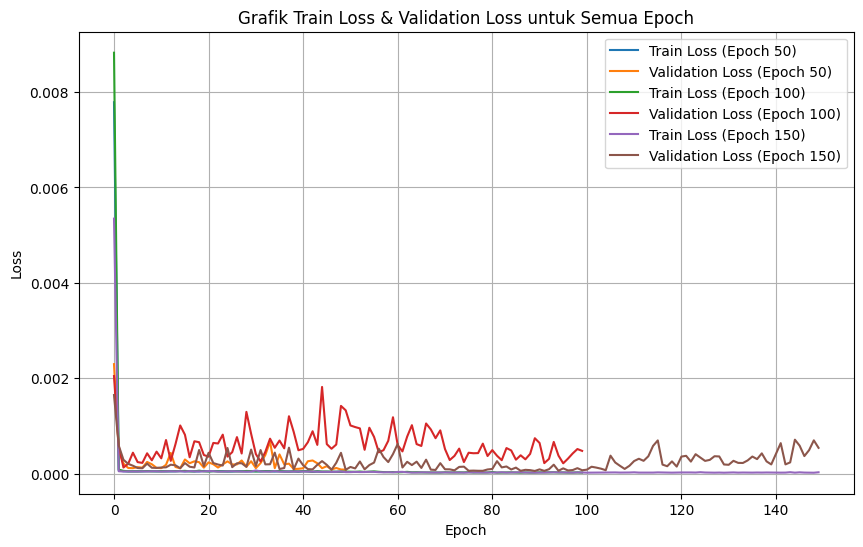

In [ ]:
# Simpan semua data loss
loss_results = {}

for epoch in [50, 100, 150]:
    print(f'\n=== Training dengan Epoch {epoch} ===')

    model = build_model()
    history = model.fit(
        X_train.reshape(X_train.shape[0], X_train.shape[1], 1),
        y_train,
        epochs=epoch,
        batch_size=32,
        validation_data=(X_test.reshape(X_test.shape[0], X_test.shape[1], 1), y_test),
        verbose=1
    )

    # Simpan hasil loss
    loss_results[epoch] = {
        'train_loss': history.history['loss'],
        'val_loss': history.history['val_loss']
    }

# Visualisasi Train Loss & Validation Loss untuk Semua Epoch
plt.figure(figsize=(10, 6))

for epoch, losses in loss_results.items():
    plt.plot(losses['train_loss'], label=f'Train Loss (Epoch {epoch})')
    plt.plot(losses['val_loss'], label=f'Validation Loss (Epoch {epoch})')

plt.title('Grafik Train Loss & Validation Loss untuk Semua Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
